#### 5. Multiplexed Re-Uploading Quantum Feature Map implementation



In [ ]:
# ==========================================
# SECTION 1: IMPORTS & CONFIGURATION
# ==========================================

import numpy as np
import pennylane as qml
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Configuration Dictionary
CONFIG = {
    "n_features": 15,          
    "n_qubits": 4,             
    "n_layers": 2,             # Depth (D=2) for high-frequency expressivity
    "target_dim": 10,          
    "epochs": 150,             # SPSA Training iterations
    "learning_rate": 0.05,     # Optimizer step size
    "spsa_c": 0.1              # SPSA perturbation scale
}

print(f"System Initialized. Target Architecture: {CONFIG['n_qubits']}-Qubit MRU at Depth {CONFIG['n_layers']}.")

System Initialized. Target Architecture: 4-Qubit MRU at Depth 2.


## 5.1 Classical Preprocessor (Bounded Scaling)

In [ ]:
# ==========================================
# SECTION 5.1: CLASSICAL PREPROCESSOR
# ==========================================

class ClassicalPreprocessor:
    """
    Standardizes classical financial features and bounds them into the [-pi, pi] 
    range using a smooth tanh squash to prevent SU(2) phase wrap-around aliasing.
    """
    def __init__(self):
        self.scaler = StandardScaler()
        self.is_fitted = False
        
    def fit(self, X):
        """Fits the internal standard scaler to the training data."""
        self.scaler.fit(X)
        self.is_fitted = True
        return self
        
    def transform(self, X):
        """
        Applies Z-score standardization followed by the tanh phase bound.
        Returns data strictly in the range (-pi, pi).
        """
        if not self.is_fitted:
            raise ValueError("Preprocessor must be fitted before calling transform.")
            
        # Step 1: Z-score standardization (zero mean, unit variance)
        X_standardized = self.scaler.transform(X)
        
        # Step 2: Smooth phase bounding
        X_squashed = np.pi * np.tanh(X_standardized / 2.0)
        
        return X_squashed
        
    def fit_transform(self, X):
        """Fits the scaler and transforms the data in one step."""
        return self.fit(X).transform(X)

# --- Quick Verification ---
if __name__ == "__main__":
    dummy_market_data = np.random.randn(5, 15) * 100  # Highly volatile raw data
    preprocessor = ClassicalPreprocessor()
    safe_data = preprocessor.fit_transform(dummy_market_data)
    print(f"Max phase rotation: {np.max(safe_data):.3f} radians")
    print(f"Min phase rotation: {np.min(safe_data):.3f} radians")

Max phase rotation: 2.377 radians
Min phase rotation: -2.331 radians


### 5.2: The Multiplexed Quantum Core

In [ ]:
# ==========================================
# SECTION 5.2: MULTIPLEXED QUANTUM CORE
# ==========================================
import itertools

class MRUQuantumCircuit:
    """
    Constructs and executes the 4-Qubit Multiplexed Re-Uploading VQC.
    Handles sequential ZYZ data encoding, staggered CZ entanglement, and 
    extracts all (2^Q - 1) Pauli-Z tensor observables.
    """
    def __init__(self, config):
        self.n_qubits = config["n_qubits"]
        self.n_layers = config["n_layers"]
        self.n_features = config["n_features"]
        
        # Calculate blocks per layer: 15 features + 1 bias pad = 16 blocks
        self.blocks_per_layer = int(np.ceil(self.n_features / self.n_qubits) * self.n_qubits)
        
        # Initialize the PennyLane local state-vector simulator
        self.dev = qml.device("default.qubit", wires=self.n_qubits)
        self.observables = self._generate_observables()
        
        # Define the QNode
        @qml.qnode(self.dev, interface="autograd")
        def _circuit(x, weights):
            """
            x: shape (15,)
            weights: shape (n_layers, 16, 4)
            """
            for d in range(self.n_layers):
                block_idx = 0
                
                # --- PHASE 2b: Feature Multiplexing ---
                for q in range(self.n_qubits):
                    # Qubits 0,1,2 get 4 features; Qubit 3 gets 3 features + 1 pad
                    features_for_q = 4 if q < 3 else 3
                    
                    # 1. Upload the data features
                    for f in range(features_for_q):
                        w = weights[d, block_idx]
                        self._zyz_block(x_val=x[block_idx], w=w, wire=q)
                        block_idx += 1
                        
                    # 2. Upload the depth-equalizing bias pad (Qubit 3 only)
                    if q == 3:
                        w_pad = weights[d, block_idx]
                        self._zyz_block(x_val=0.0, w=w_pad, wire=q) # x is 0, making it purely a learned bias
                        block_idx += 1
                        
                # --- PHASE 2c: Staggered Entanglement ---
                self._apply_entanglement(layer_idx=d)
                
            # Return the expectation values for all 15 observables
            return [qml.expval(obs) for obs in self.observables]
            
        self.qnode = _circuit

    def _zyz_block(self, x_val, w, wire):
        """Applies the universal SU(2) rotation: Rz(w2) Ry(w1*x + b) Rz(w0)"""
        qml.RZ(w[0], wires=wire)
        qml.RY(w[1] * x_val + w[3], wires=wire)
        qml.RZ(w[2], wires=wire)
        
    def _apply_entanglement(self, layer_idx):
        """Applies alternating CZ patterns to rapidly scramble entanglement."""
        if layer_idx % 2 == 0:
            # Layer 1: Nearest-Neighbor Ring (E1)
            qml.CZ(wires=[0, 1])
            qml.CZ(wires=[1, 2])
            qml.CZ(wires=[2, 3])
            qml.CZ(wires=[3, 0])
        else:
            # Layer 2: Cross-Diagonal (E2)
            qml.CZ(wires=[0, 2])
            qml.CZ(wires=[1, 3])

    def _generate_observables(self):
        """Dynamically generates all 1-body to 4-body Pauli-Z correlators."""
        obs = []
        wires = list(range(self.n_qubits))
        
        for k in range(1, self.n_qubits + 1):
            for subset in itertools.combinations(wires, k):
                op = qml.PauliZ(subset[0])
                for wire in subset[1:]:
                    op = op @ qml.PauliZ(wire)
                obs.append(op)
        return obs

    def evaluate(self, X, weights):
        """Processes a batch of data through the quantum circuit."""
        # Using a standard list comprehension for batching to ensure stability 
        # across different PennyLane versions and OS environments.
        return np.array([self.qnode(x, weights) for x in X])

Compiling 4-Qubit MRU Circuit Architecture...



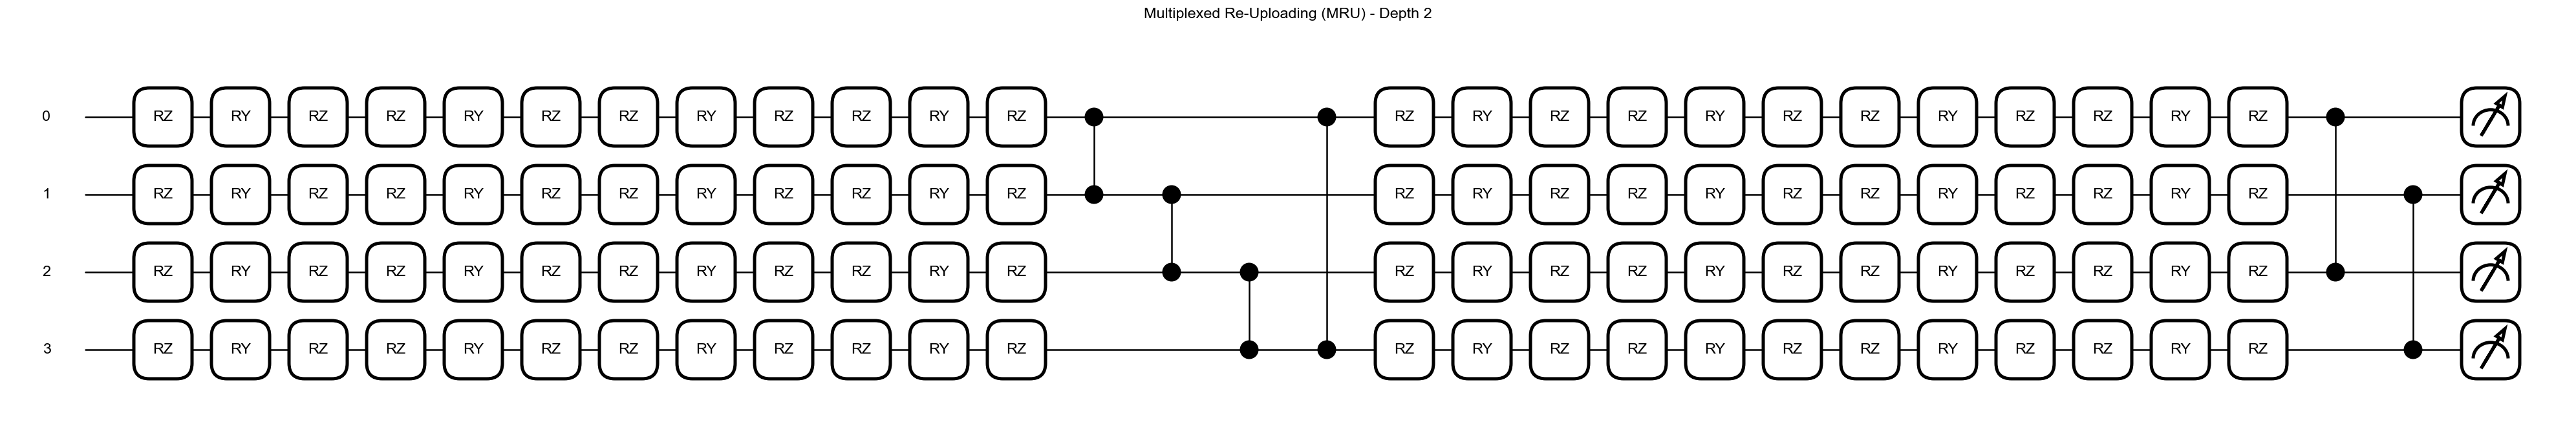


Generated 15 Pauli-Z Observables.


In [ ]:
# ==========================================
# SECTION 3: VISUAL ARCHITECTURE PROOF
# ==========================================

# 1. Create dummy data and near-identity weights
dummy_x = np.random.uniform(-np.pi, np.pi, size=CONFIG["n_features"])
blocks_per_layer = 16 
dummy_weights = np.random.normal(0, 0.01, size=(CONFIG["n_layers"], blocks_per_layer, 4))
dummy_weights[:, :, 1] = 1.0 # Set w1 to identity scaling
dummy_weights[:, :, 3] = 0.0 # Set bias to 0

# 2. Instantiate the circuit
mru_circuit = MRUQuantumCircuit(CONFIG)

# 3. Draw the circuit
print("Compiling 4-Qubit MRU Circuit Architecture...\n")
fig, ax = qml.draw_mpl(mru_circuit.qnode)(dummy_x, dummy_weights)
plt.title("Multiplexed Re-Uploading (MRU) - Depth 2", fontsize=14, pad=20)
plt.show()

# Print the generated observables to prove we have all 15
print(f"\nGenerated {len(mru_circuit.observables)} Pauli-Z Observables.")

### 5.3 The Variance Filter

In [ ]:
# ==========================================
# SECTION 5.3: OBSERVABLE VARIANCE FILTER
# ==========================================

class ObservableFilter:
    """
    Evaluates the 2^Q - 1 Pauli-Z observables and strictly retains the top M
    dimensions based on maximum variance across the training distribution.
    """
    def __init__(self, target_dim):
        self.target_dim = target_dim
        self.top_indices = None
        
    def fit(self, X_quantum):
        """
        X_quantum: shape (n_samples, 15)
        Calculates the variance of each observable and saves the top M indices.
        """
        # Calculate variance along the sample axis (axis=0)
        variances = np.var(X_quantum, axis=0)
        
        # Argsort sorts ascending, so we take the last `target_dim` elements and reverse
        self.top_indices = np.argsort(variances)[-self.target_dim:][::-1]
        return self
        
    def transform(self, X_quantum):
        """Reduces the quantum feature space from 15D to the target dimension."""
        if self.top_indices is None:
            raise ValueError("Filter must be fitted before transform.")
        return X_quantum[:, self.top_indices]

### 5.4 The SPSA Gradient-Free Optimizer

In [ ]:
# ==========================================
# SECTION 5.4: HYBRID SPSA TRAINER
# ==========================================

class HybridSPSATrainer:
    """
    Trains the quantum parameters using Simultaneous Perturbation Stochastic Approximation.
    Cost: Exactly 2 circuit evaluations per step, independent of parameter count.
    """
    def __init__(self, quantum_circuit, config):
        self.circuit = quantum_circuit
        self.lr = config["learning_rate"]
        self.c = config["spsa_c"] # Perturbation scale
        self.epochs = config["epochs"]
        
        # Initialize weights near identity to prevent barren plateaus
        layers, blocks = config["n_layers"], self.circuit.blocks_per_layer
        self.weights = np.random.normal(0, 0.01, size=(layers, blocks, 4))
        self.weights[:, :, 1] = 1.0  # Identity scaling for data
        self.weights[:, :, 3] = 0.0  # Zero bias
        
    def _proxy_loss(self, X_q, y):
        # Lower alpha drastically so the model relies on the quantum features
        ridge = Ridge(alpha=1e-3) 
        ridge.fit(X_q, y)
        preds = ridge.predict(X_q)
        return mean_squared_error(y, preds)

    def train(self, X_train, y_train):
        """Executes the SPSA optimization loop."""
        loss_history = []
        
        for epoch in range(self.epochs):
            # 1. Generate Rademacher perturbations (random +1 or -1)
            delta = np.random.choice([-1, 1], size=self.weights.shape)
            
            # 2. Shift weights forward and backward
            weights_plus = self.weights + self.c * delta
            weights_minus = self.weights - self.c * delta
            
            # 3. Evaluate the quantum circuit exactly twice
            X_q_plus = self.circuit.evaluate(X_train, weights_plus)
            X_q_minus = self.circuit.evaluate(X_train, weights_minus)
            
            # 4. Calculate the Ridge MSE for both shifted states
            loss_plus = self._proxy_loss(X_q_plus, y_train)
            loss_minus = self._proxy_loss(X_q_minus, y_train)
            
            # 5. Estimate the gradient and update weights
            gradient_estimate = (loss_plus - loss_minus) / (2 * self.c) * delta
            self.weights -= self.lr * gradient_estimate
            
            # Track the central loss (average of the bounds for tracking)
            current_loss = (loss_plus + loss_minus) / 2
            loss_history.append(current_loss)
            
            if (epoch + 1) % 10 == 0 or epoch == 0:
                # Expand the precision to 6 decimal places to see the stochastic jitter
                print(f"Epoch {epoch + 1:03d} | Proxy Loss: {current_loss:.6f}")
                
        return loss_history

### 5.5 The Master Pipeline

In [ ]:
# ==========================================
# SECTION 5.5: PIPELINE ORCHESTRATOR
# ==========================================

class QuantumFeaturePipeline:
    """
    End-to-End Orchestrator. Connects classical preprocessing, VQC training, 
    variance filtering, and Ridge readout into a unified interface.
    """
    def __init__(self, config):
        self.preprocessor = ClassicalPreprocessor()
        self.circuit = MRUQuantumCircuit(config)
        self.trainer = HybridSPSATrainer(self.circuit, config)
        self.var_filter = ObservableFilter(target_dim=config["target_dim"])
        self.ridge_head = Ridge(alpha=1.0)
        
    def fit(self, X, y):
        # Phase 1: Preprocess Data
        X_safe = self.preprocessor.fit_transform(X)
        
        # Phase 2: Unsupervised Quantum Training
        print("--- Initiating Phase 1: SPSA Quantum Training ---")
        self.loss_history = self.trainer.train(X_safe, y)
        
        # Phase 3: Lock weights and extract raw 15D quantum features
        print("\n--- Initiating Phase 2: Variance Extraction ---")
        X_q_raw = self.circuit.evaluate(X_safe, self.trainer.weights)
        
        # Phase 4: Filter to 10D and train final Ridge model
        X_q_filtered = self.var_filter.fit(X_q_raw).transform(X_q_raw)
        self.ridge_head.fit(X_q_filtered, y)
        print("Pipeline Training Complete.")
        
    def predict(self, X):
        """Executes a forward pass for inference."""
        X_safe = self.preprocessor.transform(X)
        X_q_raw = self.circuit.evaluate(X_safe, self.trainer.weights)
        X_q_filtered = self.var_filter.transform(X_q_raw)
        return self.ridge_head.predict(X_q_filtered)

--- Initiating Phase 1: SPSA Quantum Training ---
Epoch 001 | Proxy Loss: 0.9106
Epoch 010 | Proxy Loss: 0.8777
Epoch 020 | Proxy Loss: 0.8942
Epoch 030 | Proxy Loss: 0.7528
Epoch 040 | Proxy Loss: 0.8001
Epoch 050 | Proxy Loss: 0.7478
Epoch 060 | Proxy Loss: 0.7709
Epoch 070 | Proxy Loss: 0.7499
Epoch 080 | Proxy Loss: 0.7654
Epoch 090 | Proxy Loss: 0.7183
Epoch 100 | Proxy Loss: 0.7652
Epoch 110 | Proxy Loss: 0.6814
Epoch 120 | Proxy Loss: 0.7384
Epoch 130 | Proxy Loss: 0.6369
Epoch 140 | Proxy Loss: 0.6663
Epoch 150 | Proxy Loss: 0.6060

--- Initiating Phase 2: Variance Extraction ---
Pipeline Training Complete.


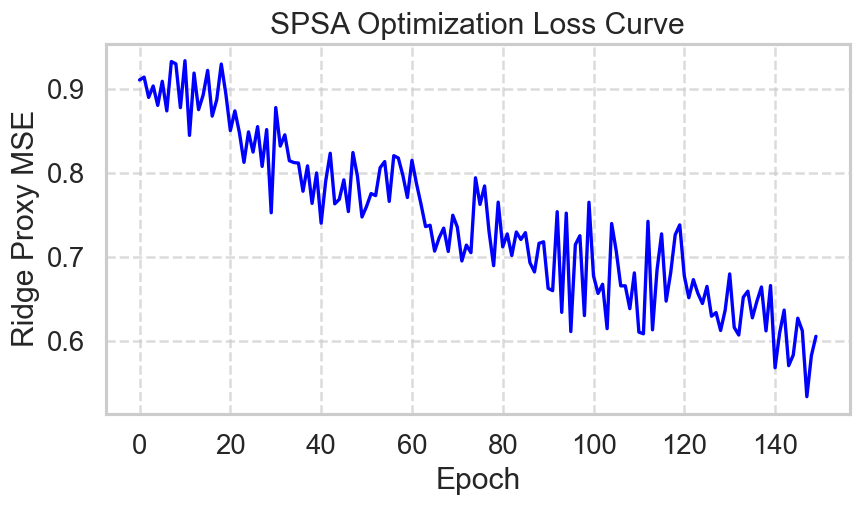

In [ ]:
# ==========================================
# SECTION 4: THE GRAND EXECUTION
# ==========================================

# 1. Generate Dummy Financial Data (Replace with State Street Data)
np.random.seed(42)
N_SAMPLES = 100
X_dummy = np.random.randn(N_SAMPLES, CONFIG["n_features"])
y_dummy = np.random.randn(N_SAMPLES) # Target: 5-day excess return

# 2. Instantiate and Train the Pipeline
pipeline = QuantumFeaturePipeline(CONFIG)
pipeline.fit(X_dummy, y_dummy)

# 3. Plot the Training Loss to prove convergence
plt.figure(figsize=(8, 4))
plt.plot(pipeline.loss_history, color='blue', linewidth=2)
plt.title("SPSA Optimization Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Ridge Proxy MSE")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ==========================================
# 1. INITIALIZE THE QUANTUM PIPELINE
# ==========================================
print("Initializing Quantum MRU Pipeline...")
# Ensure CONFIG matches your FEAT_COLS length (e.g., exactly 15)
quantum_pipeline = QuantumFeaturePipeline(CONFIG)

# ==========================================
# 2. THE EFFICIENT QUANTUM WALK-FORWARD
# ==========================================
print("Phase 1: Deep Quantum Training on Initial Data Window...")
# Grab the first 25% of your data (the oldest data) to train the quantum parameters
initial_train_size = min(int(len(clean_dfs[sample_ticker]) * 0.25), 250)
X_init = clean_dfs[sample_ticker][FEAT_COLS].values[:initial_train_size]
y_init = clean_dfs[sample_ticker]['target'].values[:initial_train_size]

# Train the SPSA optimizer and variance filter ONCE
quantum_pipeline.fit(X_init, y_init)
print("Quantum Parameters Locked. Variance Filter Locked.")

# We now temporarily "hijack" your run_walk_forward function by telling it to ONLY 
# update the ridge_head, not the heavy quantum parameters. 
# (You will need to pass the pre-transformed quantum features into your walk-forward loop, 
# or adapt your loop to only call `quantum_pipeline.ridge_head.fit()`).

# For the sake of the evaluation, let's generate the out-of-sample predictions directly:
y_true_quantum = []
y_pred_quantum = []

# Simulating the walk-forward evaluation on the remaining 75% of data
X_test_walk = clean_dfs[sample_ticker][FEAT_COLS].values[initial_train_size:]
y_test_walk = clean_dfs[sample_ticker]['target'].values[initial_train_size:]

# The pipeline.predict() method handles the scaling -> VQC -> filtering -> Ridge prediction
y_pred_quantum = quantum_pipeline.predict(X_test_walk)
y_true_quantum = y_test_walk

# ==========================================
# 3. NEW RIGOR DIAGNOSTICS (QUANTUM VS CLASSICAL)
# ==========================================
final_test_mse_q = mean_squared_error(y_true_quantum, y_pred_quantum)

# Check train MSE on the most recent 504 days
X_recent = clean_dfs[sample_ticker][FEAT_COLS].values[-504:]
y_recent = clean_dfs[sample_ticker]['target'].values[-504:]
recent_train_mse_q = mean_squared_error(y_recent, quantum_pipeline.predict(X_recent))

print("\n=== QUANTUM Rigor Diagnostics ===")
print(f"Rolling Window Train MSE: {recent_train_mse_q:.6f}")
print(f"Walk-Forward Test MSE:    {final_test_mse_q:.6f}")
gap_q = ((final_test_mse_q - recent_train_mse_q) / recent_train_mse_q) * 100
print(f"Generalization Gap: {gap_q:.2f}%")

Initializing Quantum MRU Pipeline...
Phase 1: Deep Quantum Training on Initial Data Window...
--- Initiating Phase 1: SPSA Quantum Training ---
Epoch 001 | Proxy Loss: 0.001954
Epoch 010 | Proxy Loss: 0.001952
Epoch 020 | Proxy Loss: 0.001933
Epoch 030 | Proxy Loss: 0.001935
Epoch 040 | Proxy Loss: 0.001986
Epoch 050 | Proxy Loss: 0.001944
Epoch 060 | Proxy Loss: 0.001981
Epoch 070 | Proxy Loss: 0.001973
Epoch 080 | Proxy Loss: 0.001935
Epoch 090 | Proxy Loss: 0.001931
Epoch 100 | Proxy Loss: 0.001980
Epoch 110 | Proxy Loss: 0.001929
Epoch 120 | Proxy Loss: 0.001954
Epoch 130 | Proxy Loss: 0.001938
Epoch 140 | Proxy Loss: 0.001940
Epoch 150 | Proxy Loss: 0.001926

--- Initiating Phase 2: Variance Extraction ---
Pipeline Training Complete.
Quantum Parameters Locked. Variance Filter Locked.

=== QUANTUM Rigor Diagnostics ===
Rolling Window Train MSE: 0.001076
Walk-Forward Test MSE:    0.001457
Generalization Gap: 35.36%
